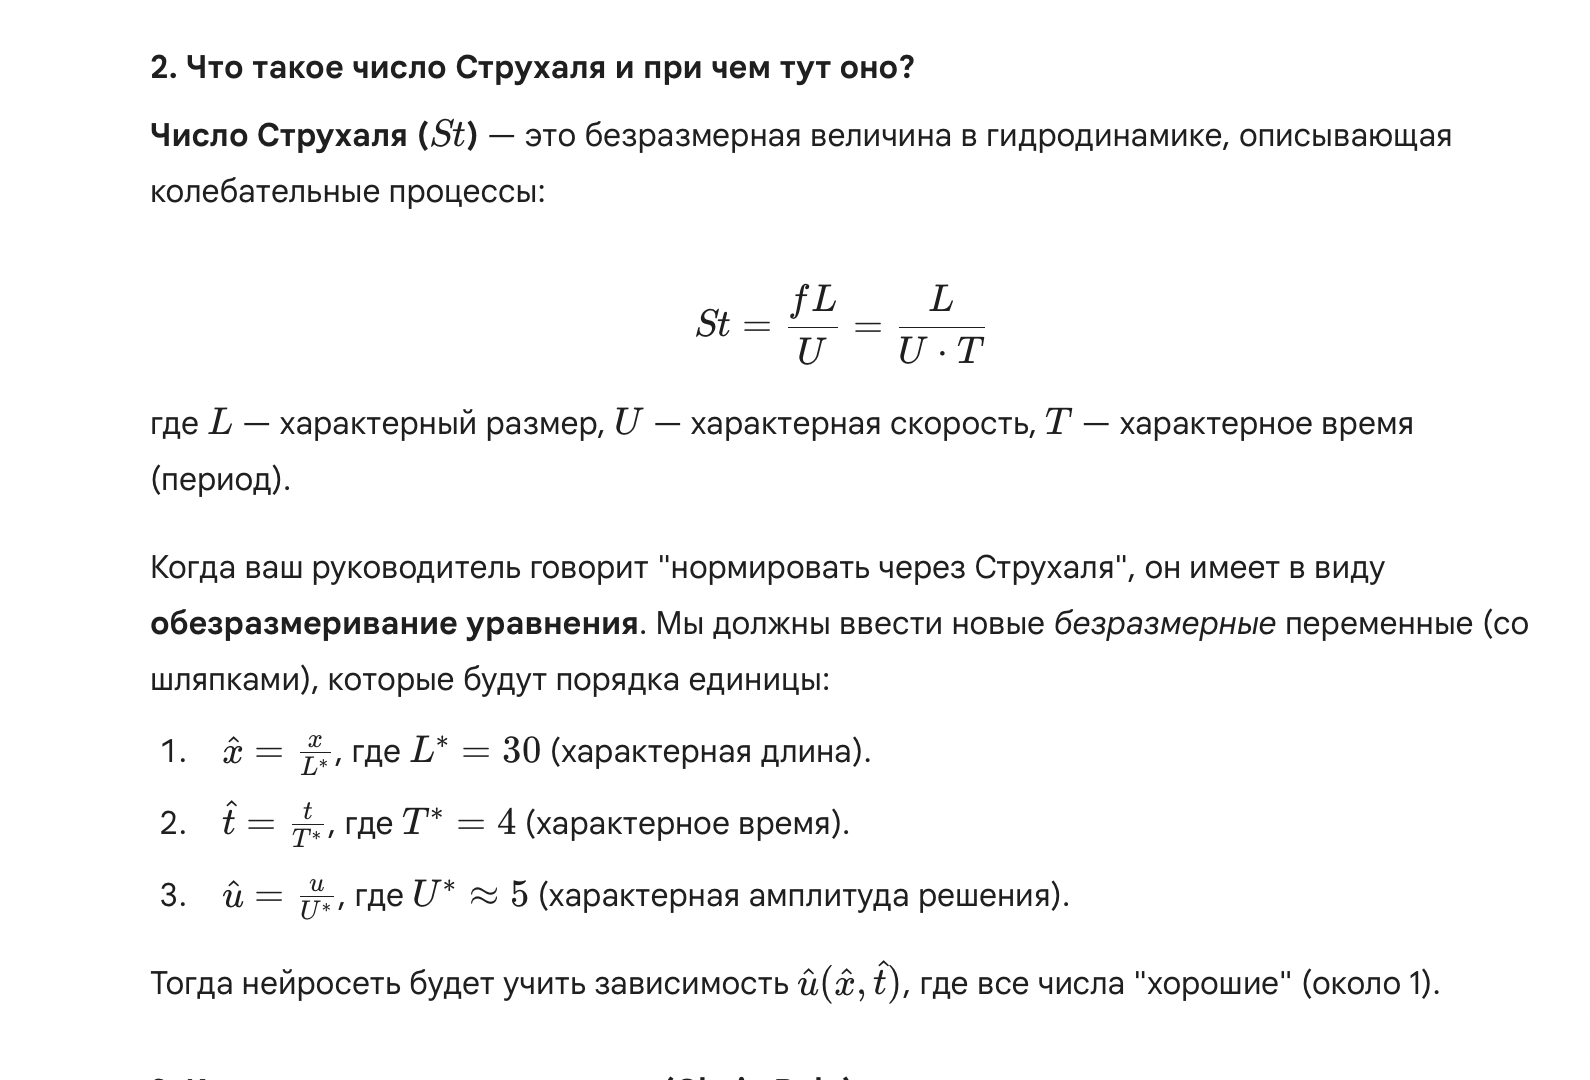

# Потановка задачи 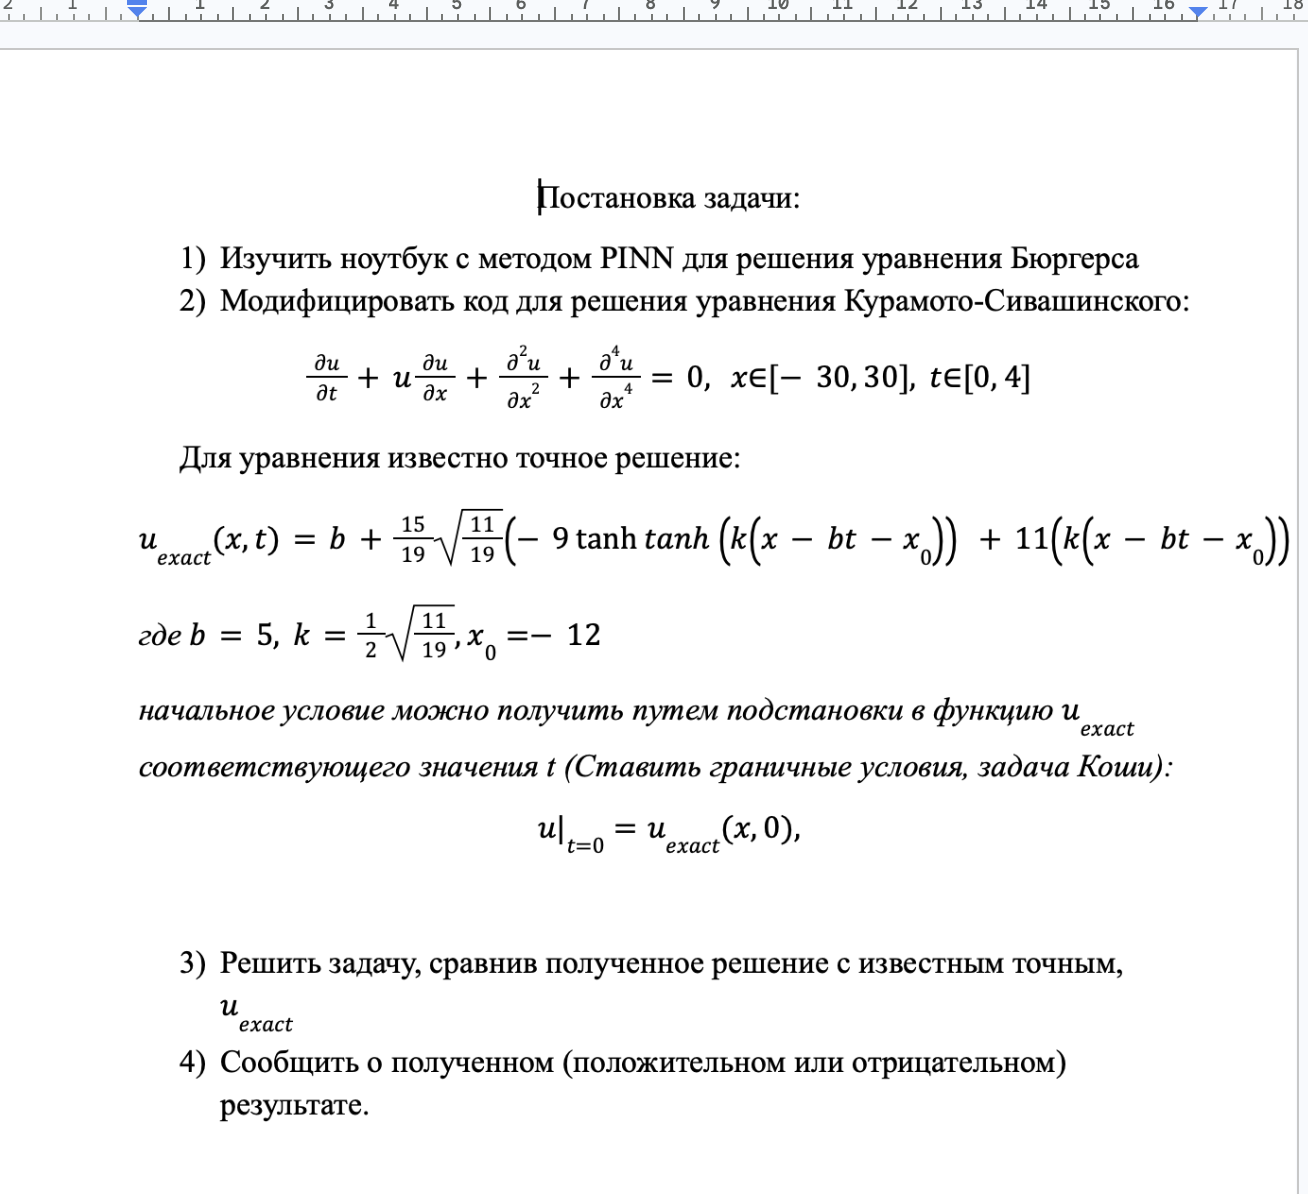
## Уравнение диф
$$ u_t+ u \cdot u_x + u_{xx} + u_{xxxx} = 0 , x \in [30,30], t \in [0,4]$$
## Точное решение 

# Init imports

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import math
from time import time

try:
    from tf_fourier_features import FourierFeatureProjection as ExternalFourierFeatureProjection
    FOURIER_BACKEND = "tf_fourier_features"
except Exception as exc:
    ExternalFourierFeatureProjection = None
    FOURIER_BACKEND = "fallback"
    print("tf_fourier_features is not available.")
    print("Install with: pip install tf-fourier-features")
    print(f"Using fallback Fourier features. Import error: {exc}")


class FallbackFourierFeatureProjection(tf.keras.layers.Layer):
    def __init__(self, gaussian_projection=16, gaussian_scale=1.0, seed=42, trainable=False, **kwargs):
        super().__init__(**kwargs)
        self.gaussian_projection = int(gaussian_projection)
        self.gaussian_scale = float(gaussian_scale)
        self.seed = int(seed)
        self.trainable_projection = bool(trainable)

    def build(self, input_shape):
        self.B = self.add_weight(
            name="B",
            shape=(1, self.gaussian_projection),
            initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=self.gaussian_scale,
                seed=self.seed,
            ),
            trainable=self.trainable_projection,
            dtype=self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        x = tf.cast(x, self.compute_dtype)
        projection = 2.0 * math.pi * tf.matmul(x, self.B)
        return tf.concat([tf.sin(projection), tf.cos(projection)], axis=-1)


def make_fourier_projection(gaussian_projection, gaussian_scale, seed):
    if ExternalFourierFeatureProjection is not None:
        return ExternalFourierFeatureProjection(
            gaussian_projection=gaussian_projection,
            gaussian_scale=gaussian_scale,
        )
    return FallbackFourierFeatureProjection(
        gaussian_projection=gaussian_projection,
        gaussian_scale=gaussian_scale,
        seed=seed,
    )


/Users/zasmina/Study/cursach/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Init Data

In [2]:
DTYPE = "float64"
tf.keras.backend.set_floatx(DTYPE)

SEED = 1234
tf.random.set_seed(SEED)
np.random.seed(SEED)

b = tf.constant(5.0, dtype=DTYPE)
k = tf.constant(0.5 * np.sqrt(11.0 / 19.0), dtype=DTYPE)
c = tf.constant((15.0 / 19.0) * np.sqrt(11.0 / 19.0), dtype=DTYPE)
x0 = tf.constant(-12.0, dtype=DTYPE)
us = tf.constant(10.0, dtype=DTYPE)


def u_exact(t, x):
    t = tf.cast(t, DTYPE)
    x = tf.cast(x, DTYPE)
    z = k * (x - b * t - x0)
    th = tf.tanh(z)
    return (b + c * (-9.0 * th + 11.0 * th**3)) / us


- linspace равновмерный выбор точек на отрезке
- reshape изменение формы массива (в даннном случаи транспонировали вектор)

In [3]:
x = np.linspace(-30.0, 30.0, 200).reshape(-1, 1)


### Постронение графика в точке (0, x) 

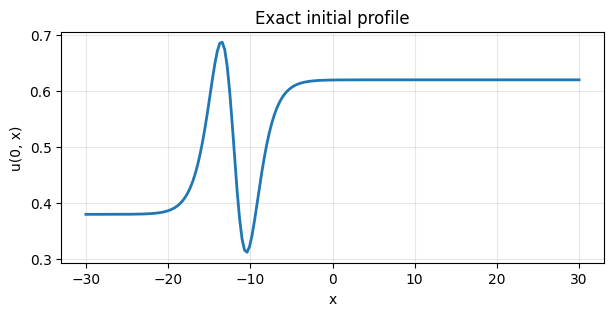

In [4]:
plt.figure(figsize=(7, 3))
plt.plot(x, u_exact(0.0, x), lw=2)
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("Exact initial profile")
plt.grid(True, alpha=0.3)
plt.show()


# Начальное условие 

In [5]:
def fun_u_0(x):
    return u_exact(tf.zeros_like(x, dtype=DTYPE), x)


# Функции описывающие невязки 


In [6]:
def fun_r(t, x, u, u_t, u_x, u_xx, u_xxxx):
    return u_t + us * u * u_x + u_xx + u_xxxx


# Параметры области 

Параметры 
tmin = 0.; tmax = 4.  

xmin = -30.; xmax = 30.  Надо изменить ? получается если нормализируем в этой функции 

In [7]:
N_0 = 300
N_r = 20000
N_b = 2000

tmin, tmax = 0.0, 4.0
xmin, xmax = -30.0, 30.0


# Границы области

In [8]:
lb = tf.constant([tmin, xmin], dtype=DTYPE)
ub = tf.constant([tmax, xmax], dtype=DTYPE)


In [9]:
# Initial condition points: t = 0
t_0 = tf.zeros((N_0, 1), dtype=DTYPE)
x_0 = tf.random.uniform((N_0, 1), lb[1], ub[1], dtype=DTYPE)
X_0 = tf.concat([t_0, x_0], axis=1)
u_0 = fun_u_0(x_0)


### Так понимаю это задание обучающего датасета 
выбираем рандомные точки для обучения (см график)

In [10]:
# Collocation points inside the time-space domain
t_r = tf.random.uniform((N_r, 1), lb[0] + 1e-6, ub[0], dtype=DTYPE)
x_r = tf.random.uniform((N_r, 1), lb[1], ub[1], dtype=DTYPE)
X_r = tf.concat([t_r, x_r], axis=1)


Граничные условия 


In [11]:
# Boundary points: x = xmin and x = xmax at identical time t_b
t_b = tf.random.uniform((N_b, 1), lb[0], ub[0], dtype=DTYPE)

x_lb = tf.ones((N_b, 1), dtype=DTYPE) * lb[1]
x_ub = tf.ones((N_b, 1), dtype=DTYPE) * ub[1]

X_lb = tf.concat([t_b, x_lb], axis=1)
X_ub = tf.concat([t_b, x_ub], axis=1)

tf.debugging.assert_near(X_lb[:, 0:1], X_ub[:, 0:1])


In [12]:
# Boundary sample sanity check
print("X_lb shape:", X_lb.shape, "X_ub shape:", X_ub.shape)
print("Same time samples on left/right:", bool(tf.reduce_all(tf.equal(X_lb[:, 0:1], X_ub[:, 0:1]))))
print("Unique x on left boundary:", np.unique(X_lb[:, 1].numpy())[:5])
print("Unique x on right boundary:", np.unique(X_ub[:, 1].numpy())[:5])


X_lb shape: (2000, 2) X_ub shape: (2000, 2)
Same time samples on left/right: True
Unique x on left boundary: [-30.]
Unique x on right boundary: [30.]


In [13]:
X_data = [X_0]
u_data = [u_0]


# График точного решения 

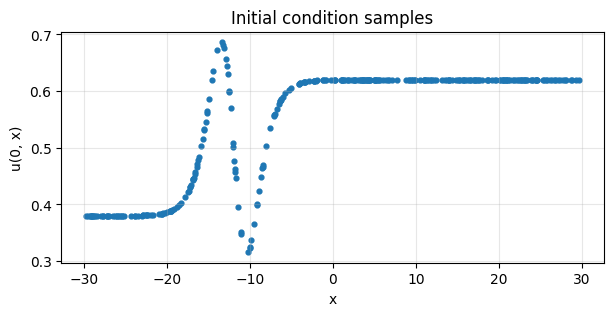

In [14]:
plt.figure(figsize=(7, 3))
plt.scatter(X_0[:, 1:2], u_0, s=12)
plt.xlabel("x")
plt.ylabel("u(0, x)")
plt.title("Initial condition samples")
plt.grid(True, alpha=0.3)
plt.show()


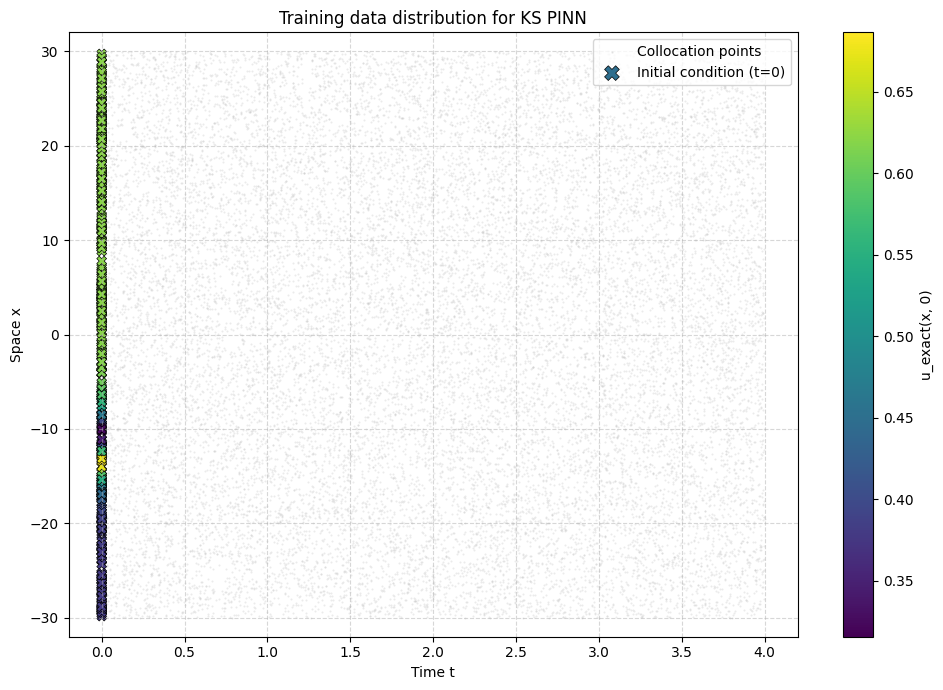

In [15]:
fig = plt.figure(figsize=(10, 7))

plt.scatter(t_r, x_r, c="silver", marker=".", s=1, alpha=0.3, label="Collocation points")
sc = plt.scatter(
    t_0,
    x_0,
    c=u_0,
    marker="X",
    s=50,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.5,
    vmin=float(tf.reduce_min(u_0)),
    vmax=float(tf.reduce_max(u_0)),
    label="Initial condition (t=0)",
)

plt.xlabel("Time t")
plt.ylabel("Space x")
plt.xlim(tmin - 0.2, tmax + 0.2)
plt.ylim(xmin - 2.0, xmax + 2.0)
plt.legend(loc="upper right", markerscale=1.5)
plt.title("Training data distribution for KS PINN")
cbar = plt.colorbar(sc)
cbar.set_label("u_exact(x, 0)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [16]:
# Scalar weights for loss terms
lambda_r = tf.constant(1.0, dtype=DTYPE)
lambda_b = tf.constant(1.0, dtype=DTYPE)
lambda_0 = tf.constant(1.0, dtype=DTYPE)

# Pointwise weights kept explicit in formulas
w_r = tf.ones((N_r, 1), dtype=DTYPE)
w_0 = tf.ones((N_0, 1), dtype=DTYPE)


Хочет начальные признаки обработать начальные условия Фурие чтобы добавить новых признаков ??? 
Которые мы скормим модели 

если есть точка tx может чет потом погуглить

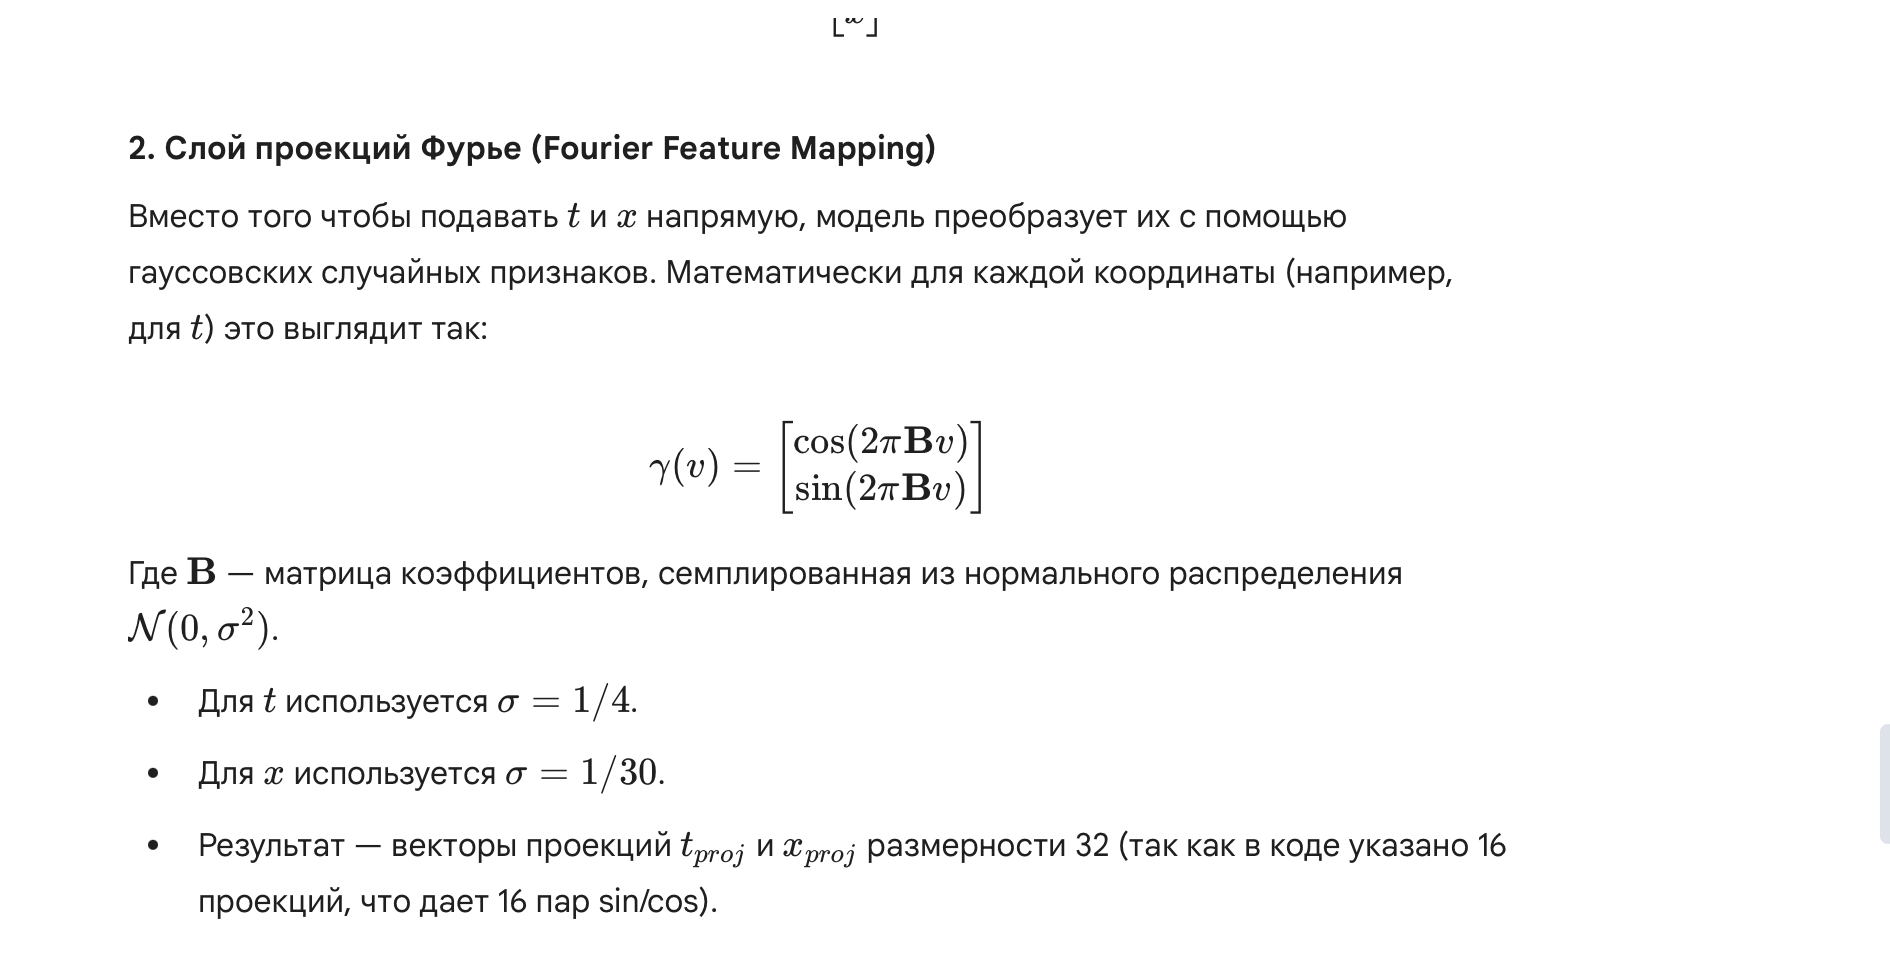

In [17]:
class MyModel(tf.keras.Model):
    def __init__(self, num_hidden_layers=4, hidden_dim=64, num_fourier=16, act="linear"):
        super().__init__()
        self.t_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 4.0,
            seed=101,
        )
        self.x_proj = make_fourier_projection(
            gaussian_projection=num_fourier,
            gaussian_scale=1.0 / 30.0,
            seed=202,
        )

        self.hidden_layers = [
            tf.keras.layers.Dense(hidden_dim, activation="tanh")
            for _ in range(num_hidden_layers)
        ]
        self.output_layer = tf.keras.layers.Dense(1, activation=act)

    def call(self, inputs):
        inputs = tf.cast(inputs, DTYPE)
        t = inputs[:, 0:1]
        x = inputs[:, 1:2]

        t_features = tf.cast(self.t_proj(t), DTYPE)
        x_features = tf.cast(self.x_proj(x), DTYPE)
        features = tf.concat([t_features, x_features], axis=1)

        h = features
        for layer in self.hidden_layers:
            h = layer(h)

        return self.output_layer(h)


Невязка

In [18]:
def get_r(model, X_r):
    t = X_r[:, 0:1]
    x = X_r[:, 1:2]

    with tf.GradientTape(persistent=True) as tape4:
        tape4.watch([t, x])
        with tf.GradientTape(persistent=True) as tape3:
            tape3.watch([t, x])
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch([t, x])
                with tf.GradientTape(persistent=True) as tape1:
                    tape1.watch([t, x])
                    u = model(tf.concat([t, x], axis=1))
                u_x = tape1.gradient(u, x)
                u_t = tape1.gradient(u, t)
            u_xx = tape2.gradient(u_x, x)
        u_xxx = tape3.gradient(u_xx, x)
    u_xxxx = tape4.gradient(u_xxx, x)

    del tape1, tape2, tape3, tape4

    return fun_r(t, x, u, u_t, u_x, u_xx, u_xxxx)


In [19]:
def get_boundary_residuals_from_exact(model, X_lb, X_ub):
    t_lb, x_lb = X_lb[:, 0:1], X_lb[:, 1:2]
    t_ub, x_ub = X_ub[:, 0:1], X_ub[:, 1:2]

    with tf.GradientTape(persistent=True) as tape2_pred:
        tape2_pred.watch([x_lb, x_ub])
        with tf.GradientTape(persistent=True) as tape1_pred:
            tape1_pred.watch([x_lb, x_ub])
            u_lb = model(tf.concat([t_lb, x_lb], axis=1))
            u_ub = model(tf.concat([t_ub, x_ub], axis=1))
        u_x_lb = tape1_pred.gradient(u_lb, x_lb)
        u_x_ub = tape1_pred.gradient(u_ub, x_ub)
    u_xx_lb = tape2_pred.gradient(u_x_lb, x_lb)
    u_xx_ub = tape2_pred.gradient(u_x_ub, x_ub)

    with tf.GradientTape(persistent=True) as tape2_exact:
        tape2_exact.watch([x_lb, x_ub])
        with tf.GradientTape(persistent=True) as tape1_exact:
            tape1_exact.watch([x_lb, x_ub])
            u_exact_lb = u_exact(t_lb, x_lb)
            u_exact_ub = u_exact(t_ub, x_ub)
        u_exact_x_lb = tape1_exact.gradient(u_exact_lb, x_lb)
        u_exact_x_ub = tape1_exact.gradient(u_exact_ub, x_ub)
    u_exact_xx_lb = tape2_exact.gradient(u_exact_x_lb, x_lb)
    u_exact_xx_ub = tape2_exact.gradient(u_exact_x_ub, x_ub)

    del tape1_pred, tape2_pred, tape1_exact, tape2_exact

    r_u = tf.concat([u_lb - u_exact_lb, u_ub - u_exact_ub], axis=0)
    r_ux = tf.concat([u_x_lb - u_exact_x_lb, u_x_ub - u_exact_x_ub], axis=0)
    r_uxx = tf.concat([u_xx_lb - u_exact_xx_lb, u_xx_ub - u_exact_xx_ub], axis=0)

    return r_u, r_ux, r_uxx


In [20]:
def compute_loss_components(
    model,
    X_r,
    X_data,
    u_data,
    X_lb,
    X_ub,
    w_r,
    w_0,
    lambda_r,
    lambda_b,
    lambda_0,
):
    r = get_r(model, X_r)
    phi_r = tf.reduce_mean(tf.square(w_r * r))

    r_u_b, r_ux_b, r_uxx_b = get_boundary_residuals_from_exact(model, X_lb, X_ub)
    phi_b_u = tf.reduce_mean(tf.square(r_u_b))
    phi_b_ux = tf.reduce_mean(tf.square(r_ux_b))
    phi_b_uxx = tf.reduce_mean(tf.square(r_uxx_b))
    phi_b = phi_b_u + phi_b_ux + phi_b_uxx

    phi_0 = tf.constant(0.0, dtype=DTYPE)
    for i in range(len(X_data)):
        u_pred = model(X_data[i])
        phi_0 += tf.reduce_mean(tf.square(w_0 * (u_data[i] - u_pred)))

    total_loss = lambda_r * phi_r + lambda_b * phi_b + lambda_0 * phi_0
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx


# Градиент 
Строится для того чтобы найти Минимум ошибки (функции потель )

In [21]:
def get_grad(
    model,
    X_r,
    X_data,
    u_data,
    X_lb,
    X_ub,
    w_r,
    w_0,
    lambda_r,
    lambda_b,
    lambda_0,
):
    with tf.GradientTape() as tape:
        total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx = compute_loss_components(
            model,
            X_r,
            X_data,
            u_data,
            X_lb,
            X_ub,
            w_r,
            w_0,
            lambda_r,
            lambda_b,
            lambda_0,
        )

    grad_theta = tape.gradient(total_loss, model.trainable_variables)
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, grad_theta


In [22]:
model = MyModel()

lr = 2e-4
optim = tf.keras.optimizers.Adam(learning_rate=lr)


Для всего графика построили пирближение 

In [23]:
x_plot = np.linspace(xmin, xmax, 400).reshape(-1, 1)
y_ref_0 = u_exact(np.full_like(x_plot, tmin), x_plot).numpy().reshape(-1)
y_ref_t = u_exact(np.full_like(x_plot, tmax), x_plot).numpy().reshape(-1)
y_min = min(y_ref_0.min(), y_ref_t.min())
y_max = max(y_ref_0.max(), y_ref_t.max())
y_pad = 0.10 * (y_max - y_min + 1e-12)
PLOT_YLIM = (y_min - y_pad, y_max + y_pad)


def plot(c=0.0, ax=None):
    t = np.full_like(x_plot, c)
    xt = np.hstack([t, x_plot])
    xt_tf = tf.convert_to_tensor(xt, dtype=DTYPE)

    u_pred = model(xt_tf).numpy().reshape(-1)
    u_ref = u_exact(t, x_plot).numpy().reshape(-1)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 3))
        created_fig = True

    ax.plot(x_plot, u_pred, lw=2, label="PINN prediction")
    ax.plot(x_plot, u_ref, "--", lw=2, label="Exact solution")
    ax.set_xlabel("x")
    ax.set_ylabel("u(t, x)")
    ax.set_title(f"Solution slice at t={c:.2f}")
    ax.set_ylim(*PLOT_YLIM)
    ax.grid(True, alpha=0.3)
    ax.legend()

    if created_fig:
        plt.tight_layout()
        plt.show()


def plot_slices(times=(0.0, 4.0)):
    fig, axes = plt.subplots(1, len(times), figsize=(6 * len(times), 3.5), sharey=True)
    if len(times) == 1:
        axes = [axes]
    for ax, current_t in zip(axes, times):
        plot(current_t, ax=ax)
    plt.tight_layout()
    plt.show()


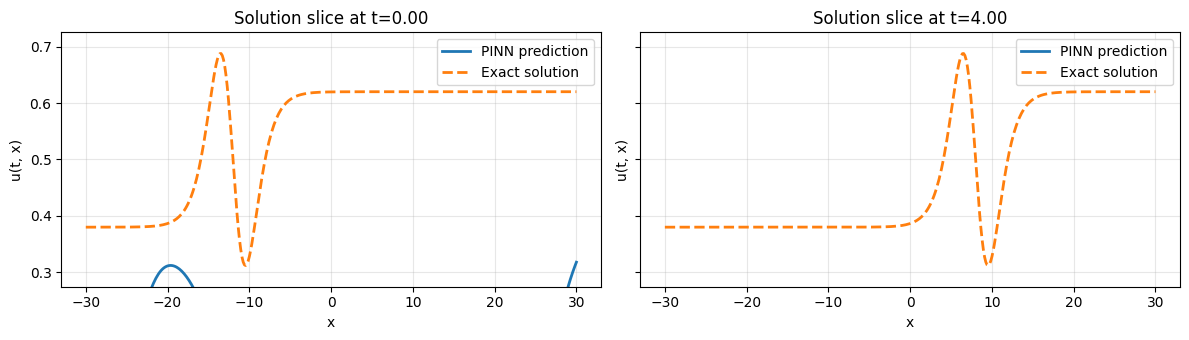

In [24]:
plot_slices((0.0, 4.0))


It 00000: total=9.02843807e-01, phi_r=4.41974557e-01, phi_b=2.46352014e-01, phi_0=2.14517236e-01


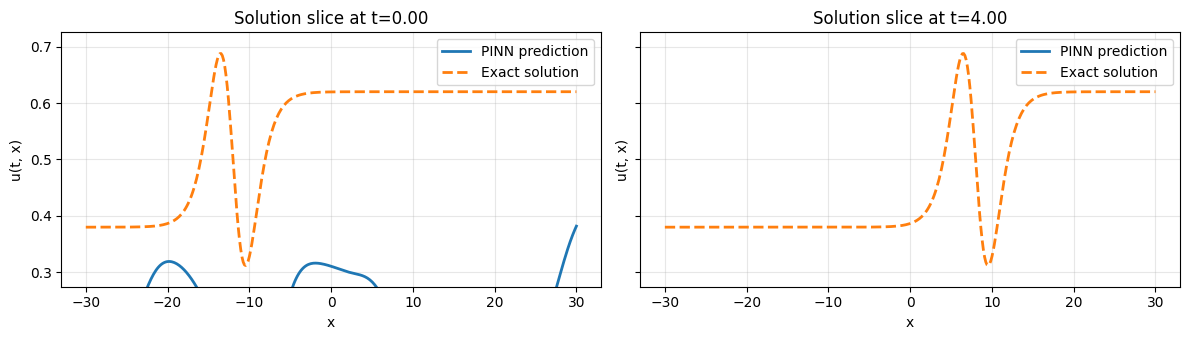

It 00050: total=1.56357195e-02, phi_r=1.18449600e-02, phi_b=1.38801464e-03, phi_0=2.40274481e-03
It 00100: total=6.33186641e-03, phi_r=4.18695159e-03, phi_b=3.91633251e-04, phi_0=1.75328158e-03
It 00150: total=4.26631692e-03, phi_r=2.43122745e-03, phi_b=2.67188378e-04, phi_0=1.56790109e-03
It 00200: total=3.26756671e-03, phi_r=1.64162361e-03, phi_b=1.92146234e-04, phi_0=1.43379686e-03
It 00250: total=2.69621195e-03, phi_r=1.22039176e-03, phi_b=1.44373927e-04, phi_0=1.33144627e-03
It 00300: total=2.33327601e-03, phi_r=9.67367361e-04, phi_b=1.13155704e-04, phi_0=1.25275294e-03
It 00350: total=2.08369763e-03, phi_r=8.02272914e-04, phi_b=9.17574807e-05, phi_0=1.18966724e-03
It 00400: total=1.90158071e-03, phi_r=6.88523649e-04, phi_b=7.64137796e-05, phi_0=1.13664328e-03
It 00450: total=1.76229369e-03, phi_r=6.07150840e-04, phi_b=6.50062868e-05, phi_0=1.09013657e-03
It 00500: total=1.65144395e-03, phi_r=5.47200721e-04, phi_b=5.62698315e-05, phi_0=1.04797340e-03
It 00550: total=1.56016940e-03

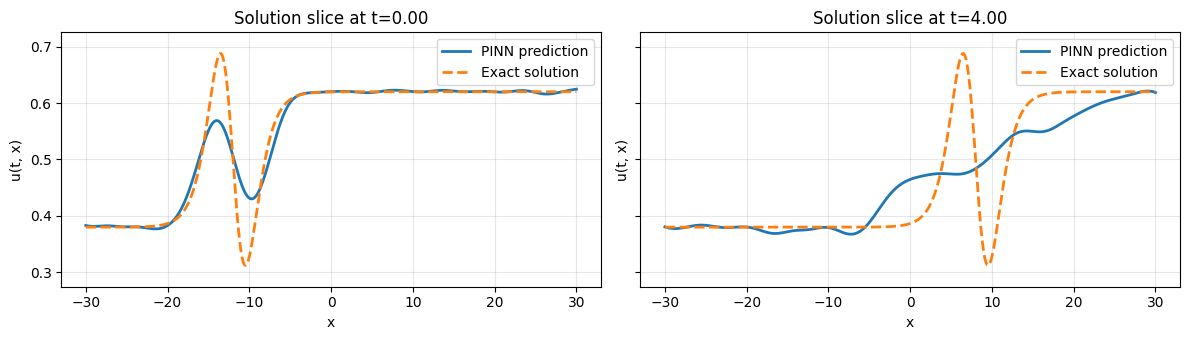

It 01050: total=1.06769773e-03, phi_r=3.48600997e-04, phi_b=1.94952838e-05, phi_0=6.99601446e-04
It 01100: total=1.03760381e-03, phi_r=3.44662557e-04, phi_b=1.80730258e-05, phi_0=6.74868223e-04
It 01150: total=1.00940638e-03, phi_r=3.41398586e-04, phi_b=1.67891609e-05, phi_0=6.51218637e-04
It 01200: total=9.82923689e-04, phi_r=3.38649005e-04, phi_b=1.56295439e-05, phi_0=6.28645140e-04
It 01250: total=9.57995895e-04, phi_r=3.36282043e-04, phi_b=1.45818826e-05, phi_0=6.07131970e-04
It 01300: total=9.34480373e-04, phi_r=3.34190626e-04, phi_b=1.36352446e-05, phi_0=5.86654502e-04
It 01350: total=9.12248591e-04, phi_r=3.32289501e-04, phi_b=1.27797635e-05, phi_0=5.67179326e-04
It 01400: total=8.91184148e-04, phi_r=3.30512714e-04, phi_b=1.20064710e-05, phi_0=5.48664962e-04
It 01450: total=8.71181497e-04, phi_r=3.28811230e-04, phi_b=1.13072035e-05, phi_0=5.31063063e-04
It 01500: total=8.52145068e-04, phi_r=3.27150579e-04, phi_b=1.06745439e-05, phi_0=5.14319944e-04
It 01550: total=8.33988576e-04

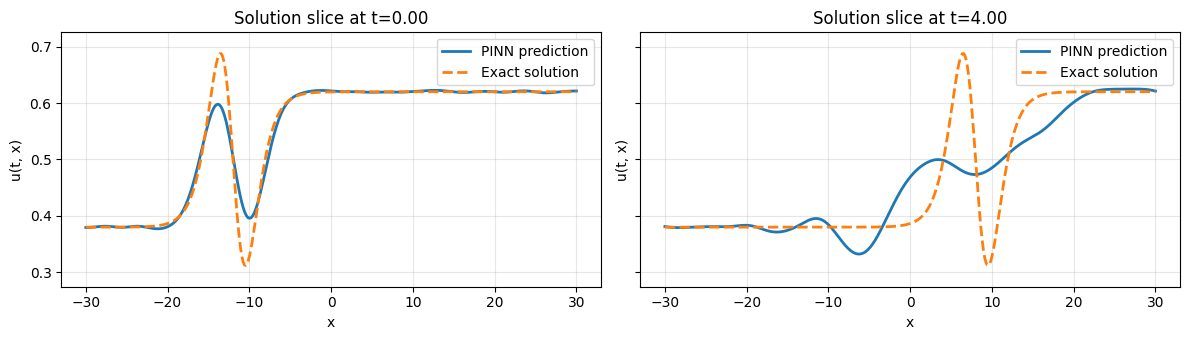

It 02050: total=6.87230304e-04, phi_r=3.09846788e-04, phi_b=6.58299430e-06, phi_0=3.70800523e-04
It 02100: total=6.75099661e-04, phi_r=3.08494979e-04, phi_b=6.37192279e-06, phi_0=3.60232759e-04
It 02150: total=6.63319880e-04, phi_r=3.07204167e-04, phi_b=6.17554820e-06, phi_0=3.49940166e-04
It 02200: total=6.51872995e-04, phi_r=3.05974664e-04, phi_b=5.99184205e-06, phi_0=3.39906489e-04
It 02250: total=6.40742612e-04, phi_r=3.04804544e-04, phi_b=5.81896517e-06, phi_0=3.30119102e-04
It 02300: total=6.29913357e-04, phi_r=3.03689606e-04, phi_b=5.65526653e-06, phi_0=3.20568485e-04
It 02350: total=6.19370370e-04, phi_r=3.02623436e-04, phi_b=5.49928254e-06, phi_0=3.11247652e-04
It 02400: total=6.09098865e-04, phi_r=3.01597581e-04, phi_b=5.34973575e-06, phi_0=3.02151548e-04
It 02450: total=5.99083800e-04, phi_r=3.00601838e-04, phi_b=5.20553224e-06, phi_0=2.93276430e-04
It 02500: total=5.89309673e-04, phi_r=2.99624639e-04, phi_b=5.06575696e-06, phi_0=2.84619278e-04
It 02550: total=5.79760440e-04

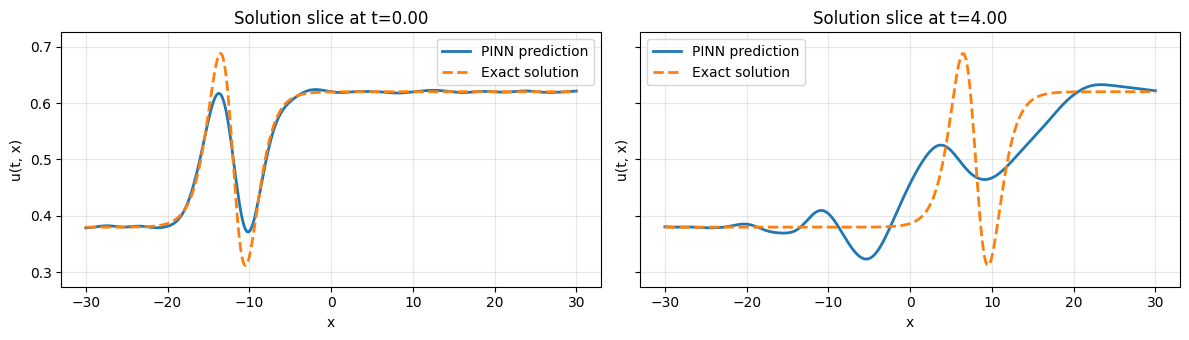

It 03050: total=4.93089474e-04, phi_r=2.86888418e-04, phi_b=3.70436892e-06, phi_0=2.02496687e-04
It 03100: total=4.85005088e-04, phi_r=2.85370550e-04, phi_b=3.59484881e-06, phi_0=1.96039689e-04
It 03150: total=4.76990503e-04, phi_r=2.83787486e-04, phi_b=3.48805562e-06, phi_0=1.89714961e-04
It 03200: total=4.69041849e-04, phi_r=2.82142299e-04, phi_b=3.38405989e-06, phi_0=1.83515490e-04
It 03250: total=4.61156546e-04, phi_r=2.80438384e-04, phi_b=3.28290114e-06, phi_0=1.77435260e-04
It 03300: total=4.53333072e-04, phi_r=2.78679143e-04, phi_b=3.18458552e-06, phi_0=1.71469343e-04
It 03350: total=4.45570729e-04, phi_r=2.76867735e-04, phi_b=3.08908556e-06, phi_0=1.65613908e-04
It 03400: total=4.37869404e-04, phi_r=2.75006873e-04, phi_b=2.99634138e-06, phi_0=1.59866189e-04
It 03450: total=4.30229352e-04, phi_r=2.73098697e-04, phi_b=2.90626279e-06, phi_0=1.54224392e-04
It 03500: total=4.22651003e-04, phi_r=2.71144700e-04, phi_b=2.81873186e-06, phi_0=1.48687572e-04
It 03550: total=4.15134817e-04

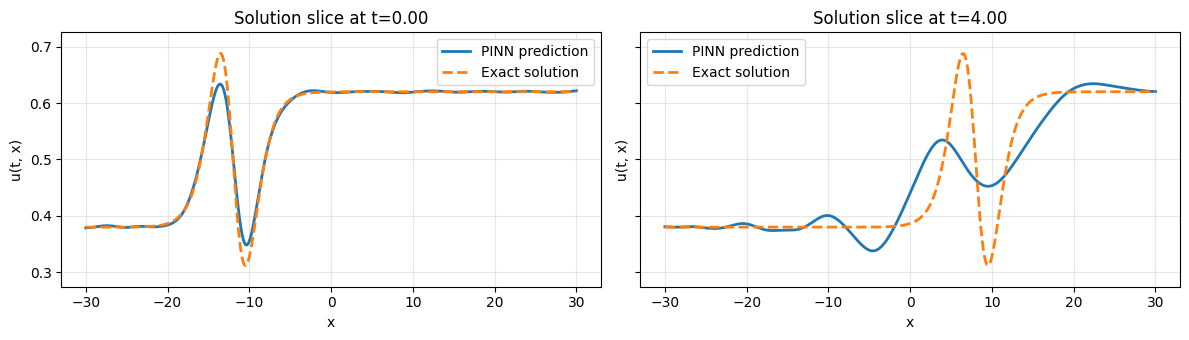

It 04050: total=3.43478644e-04, phi_r=2.46578686e-04, phi_b=1.97013299e-06, phi_0=9.49298243e-05
It 04100: total=3.36690788e-04, phi_r=2.44052561e-04, phi_b=1.89774156e-06, phi_0=9.07404861e-05
It 04150: total=3.29985778e-04, phi_r=2.41480204e-04, phi_b=1.82545792e-06, phi_0=8.66801161e-05
It 04200: total=3.23370729e-04, phi_r=2.38864617e-04, phi_b=1.75332733e-06, phi_0=8.27527839e-05
It 04250: total=3.16853906e-04, phi_r=2.36209699e-04, phi_b=1.68150124e-06, phi_0=7.89627055e-05
It 04300: total=3.10444497e-04, phi_r=2.33520182e-04, phi_b=1.61024580e-06, phi_0=7.53140691e-05
It 04350: total=3.04152263e-04, phi_r=2.30801501e-04, phi_b=1.53994151e-06, phi_0=7.18108202e-05
It 04400: total=2.97987053e-04, phi_r=2.28059564e-04, phi_b=1.47107207e-06, phi_0=6.84564172e-05
It 04450: total=2.91958231e-04, phi_r=2.25300459e-04, phi_b=1.40420112e-06, phi_0=6.52535709e-05
It 04500: total=2.86074049e-04, phi_r=2.22530122e-04, phi_b=1.33993753e-06, phi_0=6.22039896e-05
It 04550: total=2.80341059e-04

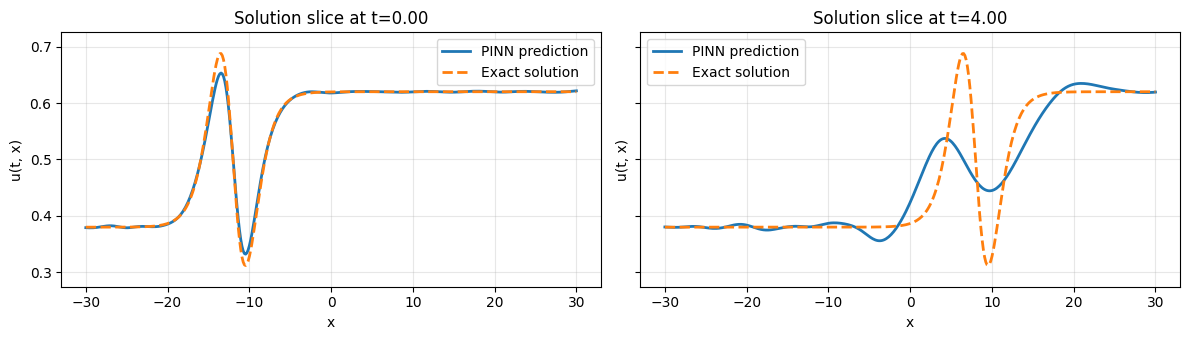

It 05050: total=2.32860401e-04, phi_r=1.93399295e-04, phi_b=8.99559844e-07, phi_0=3.85615466e-05
It 05100: total=2.43219531e-04, phi_r=1.98570719e-04, phi_b=5.02642480e-06, phi_0=3.96223864e-05
It 05150: total=2.25511432e-04, phi_r=1.88517456e-04, phi_b=8.57997053e-07, phi_0=3.61359798e-05
It 05200: total=2.21945024e-04, phi_r=1.86382096e-04, phi_b=8.44859497e-07, phi_0=3.47180691e-05
It 05250: total=2.18439352e-04, phi_r=1.84105024e-04, phi_b=8.30936819e-07, phi_0=3.35033913e-05
It 05300: total=2.14982612e-04, phi_r=1.81839104e-04, phi_b=8.17761241e-07, phi_0=3.23257473e-05
It 05350: total=2.11573897e-04, phi_r=1.79613834e-04, phi_b=8.06021835e-07, phi_0=3.11540412e-05
It 05400: total=2.08662596e-04, phi_r=1.77742692e-04, phi_b=8.45812045e-07, phi_0=3.00740925e-05
It 05450: total=2.05472764e-04, phi_r=1.75517862e-04, phi_b=7.92050280e-07, phi_0=2.91628523e-05
It 05500: total=2.02399834e-04, phi_r=1.73230279e-04, phi_b=7.64068151e-07, phi_0=2.84054870e-05
It 05550: total=1.99410445e-04

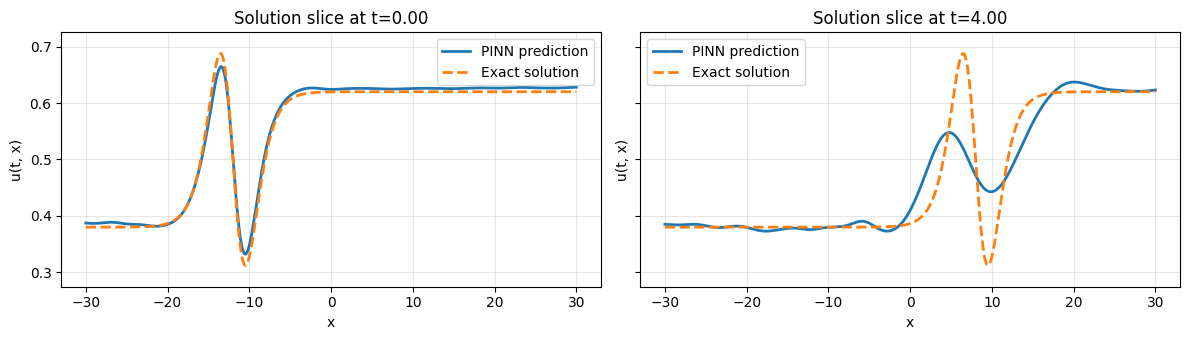

It 06050: total=1.73748700e-04, phi_r=1.51786198e-04, phi_b=8.40740796e-07, phi_0=2.11217613e-05
It 06100: total=1.71043400e-04, phi_r=1.50590021e-04, phi_b=6.28243628e-07, phi_0=1.98251352e-05
It 06150: total=1.68777412e-04, phi_r=1.48963254e-04, phi_b=6.18923727e-07, phi_0=1.91952347e-05
It 06200: total=1.66519737e-04, phi_r=1.47270558e-04, phi_b=6.09279245e-07, phi_0=1.86399001e-05
It 06250: total=1.64266626e-04, phi_r=1.45562250e-04, phi_b=5.99613405e-07, phi_0=1.81047630e-05
It 06300: total=1.62017284e-04, phi_r=1.43839759e-04, phi_b=5.89885218e-07, phi_0=1.75876399e-05
It 06350: total=1.63140711e-04, phi_r=1.42402782e-04, phi_b=2.54790129e-06, phi_0=1.81900283e-05
It 06400: total=1.58205975e-04, phi_r=1.40875073e-04, phi_b=6.26380072e-07, phi_0=1.67045214e-05
It 06450: total=1.56155741e-04, phi_r=1.39232068e-04, phi_b=5.56764339e-07, phi_0=1.63669095e-05
It 06500: total=1.54211623e-04, phi_r=1.37715781e-04, phi_b=5.48478530e-07, phi_0=1.59473633e-05
It 06550: total=1.52266638e-04

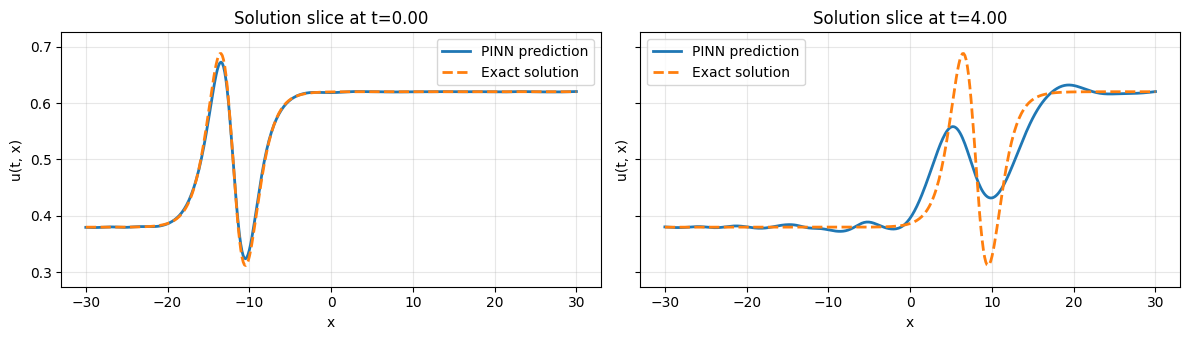

It 07050: total=1.34888458e-04, phi_r=1.22188766e-04, phi_b=4.64820555e-07, phi_0=1.22348714e-05
It 07100: total=1.33284387e-04, phi_r=1.20909214e-04, phi_b=4.58485047e-07, phi_0=1.19166877e-05
It 07150: total=2.05958747e-04, phi_r=1.48109959e-04, phi_b=1.33012963e-05, phi_0=4.45474921e-05
It 07200: total=1.30292999e-04, phi_r=1.18630281e-04, phi_b=4.60709010e-07, phi_0=1.12020094e-05
It 07250: total=1.28732152e-04, phi_r=1.16983581e-04, phi_b=4.52859696e-07, phi_0=1.12957114e-05
It 07300: total=1.27436796e-04, phi_r=1.16297515e-04, phi_b=4.72130897e-07, phi_0=1.06671494e-05
It 07350: total=1.25802476e-04, phi_r=1.14596078e-04, phi_b=4.32415316e-07, phi_0=1.07739823e-05
It 07400: total=1.24316727e-04, phi_r=1.13450810e-04, phi_b=4.21510900e-07, phi_0=1.04444064e-05
It 07450: total=1.22833704e-04, phi_r=1.12268843e-04, phi_b=4.17077850e-07, phi_0=1.01477833e-05
It 07500: total=1.25473841e-04, phi_r=1.14897445e-04, phi_b=1.63213556e-06, phi_0=8.94426042e-06
It 07550: total=1.20051711e-04

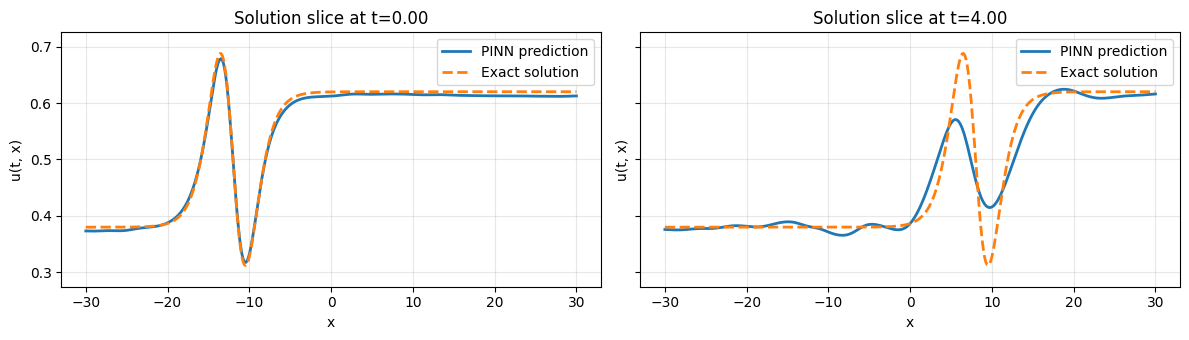

It 08050: total=1.06616075e-04, phi_r=9.85186048e-05, phi_b=3.95466481e-07, phi_0=7.70200377e-06
It 08100: total=2.08137272e-04, phi_r=1.28204154e-04, phi_b=5.48869287e-05, phi_0=2.50461896e-05
It 08150: total=1.03875271e-04, phi_r=9.59412905e-05, phi_b=3.96372981e-07, phi_0=7.53760781e-06
It 08200: total=1.02481026e-04, phi_r=9.46938830e-05, phi_b=3.60723331e-07, phi_0=7.42642010e-06
It 08250: total=1.26975757e-04, phi_r=1.00806569e-04, phi_b=9.83366307e-06, phi_0=1.63355248e-05
It 08300: total=1.00012581e-04, phi_r=9.21936875e-05, phi_b=3.88653157e-07, phi_0=7.43024002e-06
It 08350: total=1.00805138e-04, phi_r=9.30139721e-05, phi_b=1.29819083e-06, phi_0=6.49297465e-06
It 08400: total=9.75257638e-05, phi_r=9.05990453e-05, phi_b=3.83614359e-07, phi_0=6.54310416e-06
It 08450: total=9.59578018e-05, phi_r=8.88958701e-05, phi_b=3.47062406e-07, phi_0=6.71486932e-06
It 08500: total=1.08185496e-04, phi_r=9.06252262e-05, phi_b=2.78351044e-06, phi_0=1.47767596e-05
It 08550: total=9.34482083e-05

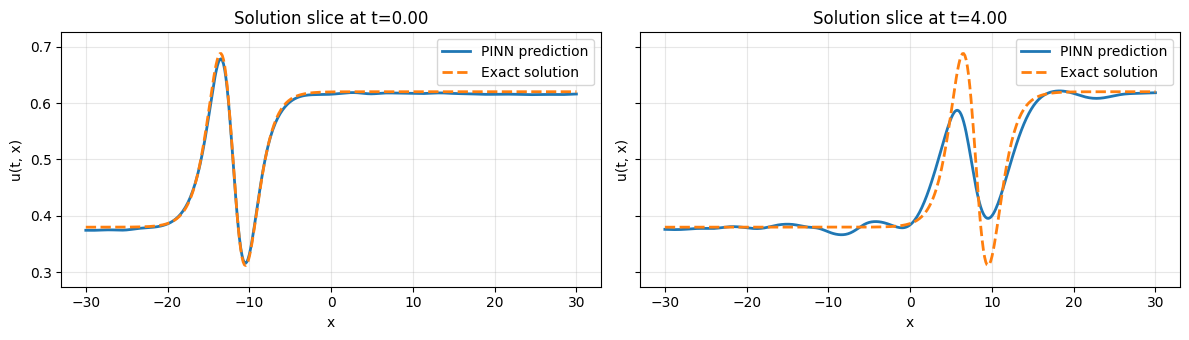

It 09050: total=8.02278165e-05, phi_r=7.48052460e-05, phi_b=3.25312748e-07, phi_0=5.09725773e-06
It 09100: total=7.88817283e-05, phi_r=7.36047185e-05, phi_b=3.23171034e-07, phi_0=4.95383879e-06
It 09150: total=8.21596362e-05, phi_r=7.29918728e-05, phi_b=2.72125244e-06, phi_0=6.44651093e-06
It 09200: total=7.62813325e-05, phi_r=7.11887848e-05, phi_b=3.22339904e-07, phi_0=4.77020781e-06
It 09250: total=7.75602770e-05, phi_r=7.04184442e-05, phi_b=7.85409581e-07, phi_0=6.35642324e-06
It 09300: total=7.36206535e-05, phi_r=6.87689064e-05, phi_b=3.26575400e-07, phi_0=4.52517165e-06
It 09350: total=8.10359083e-05, phi_r=7.13025886e-05, phi_b=3.55480946e-06, phi_0=6.17851019e-06
It 09400: total=7.09768040e-05, phi_r=6.62656624e-05, phi_b=3.56538083e-07, phi_0=4.35460357e-06
It 09450: total=6.96570847e-05, phi_r=6.49504881e-05, phi_b=3.36341729e-07, phi_0=4.37025484e-06
It 09500: total=7.11080591e-05, phi_r=6.59291463e-05, phi_b=1.01422437e-06, phi_0=4.16468840e-06
It 09550: total=6.68793244e-05

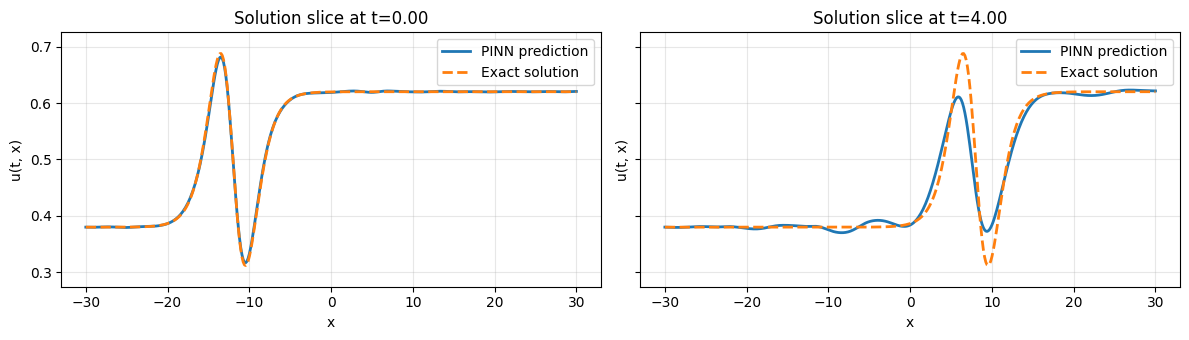

It 10050: total=5.33982542e-05, phi_r=5.01205910e-05, phi_b=3.17853468e-07, phi_0=2.95980974e-06
It 10100: total=6.25127428e-05, phi_r=5.40104838e-05, phi_b=3.45179857e-06, phi_0=5.05046048e-06
It 10150: total=5.07679626e-05, phi_r=4.76696797e-05, phi_b=3.26488003e-07, phi_0=2.77179494e-06
It 10200: total=5.19238874e-05, phi_r=4.69025260e-05, phi_b=9.24446633e-07, phi_0=4.09691471e-06
It 10250: total=8.60617743e-05, phi_r=5.15398016e-05, phi_b=1.45037846e-05, phi_0=2.00181881e-05
It 10300: total=4.69552397e-05, phi_r=4.40045346e-05, phi_b=3.31584473e-07, phi_0=2.61912064e-06
It 10350: total=5.01884514e-05, phi_r=4.43111081e-05, phi_b=2.01567581e-06, phi_0=3.86166741e-06
It 10400: total=4.45105463e-05, phi_r=4.18287930e-05, phi_b=3.77445688e-07, phi_0=2.30430765e-06
It 10450: total=5.26786353e-05, phi_r=4.35442010e-05, phi_b=3.35425135e-06, phi_0=5.78018300e-06
It 10500: total=4.18963321e-05, phi_r=3.93681274e-05, phi_b=3.21022158e-07, phi_0=2.20718256e-06
It 10550: total=5.37939304e-05

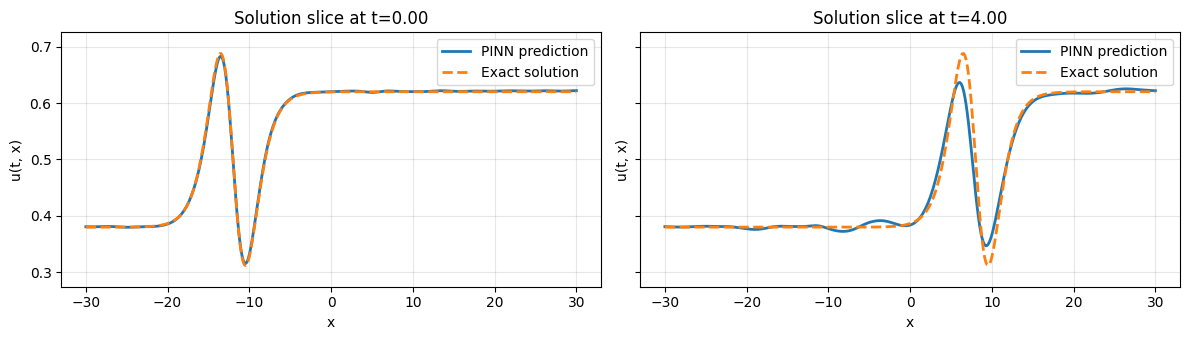

It 11050: total=3.01751654e-05, phi_r=2.78615707e-05, phi_b=5.57905585e-07, phi_0=1.75568911e-06
It 11100: total=2.89209126e-05, phi_r=2.69569604e-05, phi_b=3.85609093e-07, phi_0=1.57834310e-06
It 11150: total=2.76730243e-05, phi_r=2.60335758e-05, phi_b=3.14586290e-07, phi_0=1.32486228e-06
It 11200: total=4.43154421e-05, phi_r=3.05678849e-05, phi_b=5.29569460e-06, phi_0=8.45186265e-06
It 11250: total=2.59965475e-05, phi_r=2.43853779e-05, phi_b=3.59168247e-07, phi_0=1.25200136e-06
It 11300: total=2.54546851e-05, phi_r=2.35945463e-05, phi_b=5.41506205e-07, phi_0=1.31863263e-06
It 11350: total=2.41710941e-05, phi_r=2.26713791e-05, phi_b=3.11842080e-07, phi_0=1.18787293e-06
It 11400: total=2.53041511e-05, phi_r=2.32046280e-05, phi_b=8.16939471e-07, phi_0=1.28258362e-06
It 11450: total=2.29226318e-05, phi_r=2.13876074e-05, phi_b=4.16071178e-07, phi_0=1.11895325e-06
It 11500: total=2.40447108e-05, phi_r=2.13749906e-05, phi_b=9.30336747e-07, phi_0=1.73938346e-06
It 11550: total=2.10681839e-05

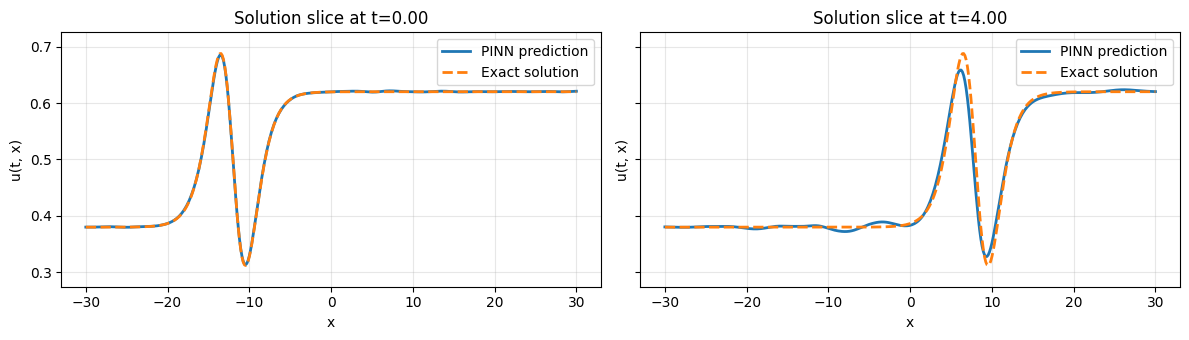

It 12050: total=1.57512721e-04, phi_r=7.40467948e-05, phi_b=3.50259958e-05, phi_0=4.84399302e-05
It 12100: total=1.49863666e-05, phi_r=1.38942454e-05, phi_b=3.24250922e-07, phi_0=7.67870258e-07
It 12150: total=1.43125614e-05, phi_r=1.34576205e-05, phi_b=2.77713680e-07, phi_0=5.77227212e-07
It 12200: total=1.38797206e-05, phi_r=1.30525519e-05, phi_b=2.75694093e-07, phi_0=5.51474533e-07
It 12250: total=2.23509479e-05, phi_r=1.55190439e-05, phi_b=2.53846119e-06, phi_0=4.29344272e-06
It 12300: total=1.32276889e-05, phi_r=1.23895504e-05, phi_b=2.91772080e-07, phi_0=5.46366388e-07
It 12350: total=1.27724723e-05, phi_r=1.20086592e-05, phi_b=2.70864059e-07, phi_0=4.92949054e-07
It 12400: total=1.21107414e-04, phi_r=4.45872379e-05, phi_b=5.57657370e-05, phi_0=2.07544390e-05
It 12450: total=1.26099181e-05, phi_r=1.15937315e-05, phi_b=5.31172599e-07, phi_0=4.85013973e-07
It 12500: total=1.40499881e-05, phi_r=1.20340745e-05, phi_b=7.44552002e-07, phi_0=1.27136156e-06
It 12550: total=1.26286155e-05

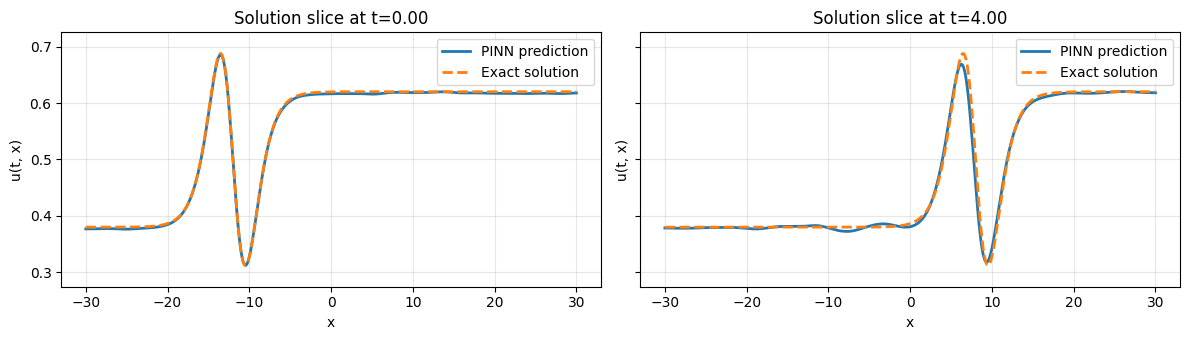


Computation time: 44227.61 seconds
History keys: ['step', 'total', 'phi_r', 'phi_b', 'phi_0', 'phi_b_u', 'phi_b_ux', 'phi_b_uxx']


In [25]:
@tf.function
def train_step():
    total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx, grad_theta = get_grad(
        model,
        X_r,
        X_data,
        u_data,
        X_lb,
        X_ub,
        w_r,
        w_0,
        lambda_r,
        lambda_b,
        lambda_0,
    )
    optim.apply_gradients(zip(grad_theta, model.trainable_variables))
    return total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx


N = 13000
history = {
    "step": [],
    "total": [],
    "phi_r": [],
    "phi_b": [],
    "phi_0": [],
    "phi_b_u": [],
    "phi_b_ux": [],
    "phi_b_uxx": [],
}

t0 = time()

for i in range(N + 1):
    total_loss, phi_r, phi_b, phi_0, phi_b_u, phi_b_ux, phi_b_uxx = train_step()

    history["step"].append(i)
    history["total"].append(float(total_loss))
    history["phi_r"].append(float(phi_r))
    history["phi_b"].append(float(phi_b))
    history["phi_0"].append(float(phi_0))
    history["phi_b_u"].append(float(phi_b_u))
    history["phi_b_ux"].append(float(phi_b_ux))
    history["phi_b_uxx"].append(float(phi_b_uxx))

    if i % 50 == 0:
        print(
            f"It {i:05d}: total={float(total_loss):.8e}, "
            f"phi_r={float(phi_r):.8e}, phi_b={float(phi_b):.8e}, phi_0={float(phi_0):.8e}"
        )

    if i % 1000 == 0:
        plot_slices((0.0, 4.0))

print(f"\nComputation time: {time() - t0:.2f} seconds")
print("History keys:", list(history.keys()))


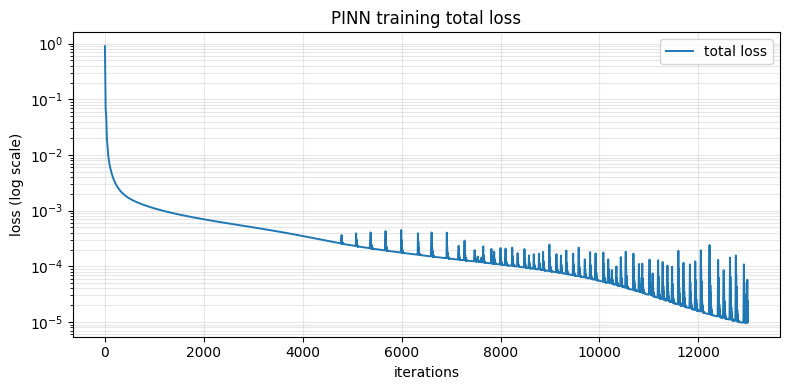

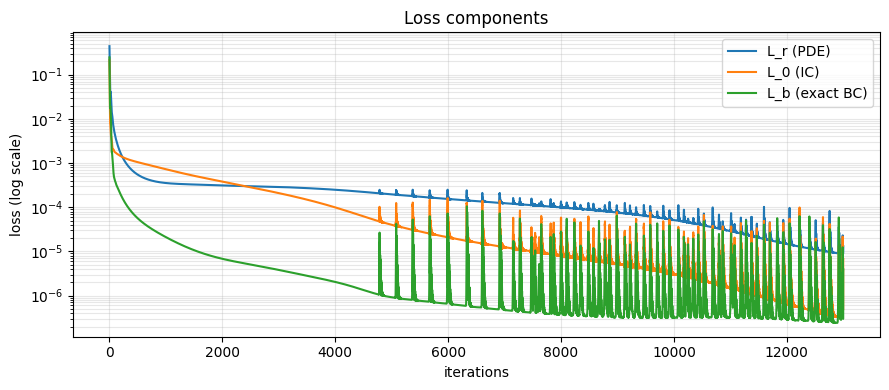

In [26]:
# Training curves: total loss in log scale + components
steps = np.array(history["step"])
total = np.array(history["total"])
eps = 1e-12

plt.figure(figsize=(8, 4))
plt.semilogy(steps, total + eps, lw=1.4, label="total loss")
plt.xlabel("iterations")
plt.ylabel("loss (log scale)")
plt.title("PINN training total loss")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.semilogy(steps, np.array(history["phi_r"]) + eps, label="L_r (PDE)")
plt.semilogy(steps, np.array(history["phi_0"]) + eps, label="L_0 (IC)")
plt.semilogy(steps, np.array(history["phi_b"]) + eps, label="L_b (exact BC)")
plt.xlabel("iterations")
plt.ylabel("loss (log scale)")
plt.title("Loss components")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Top jumps (step, relative_change):
step=12230, rel_change=2.705906e+00
step=12054, rel_change=1.535390e+00
step=12763, rel_change=1.520416e+00
step=12645, rel_change=1.381574e+00
step=12235, rel_change=1.249937e+00
step=12926, rel_change=1.108316e+00
step=12236, rel_change=1.037147e+00
step=12769, rel_change=9.875857e-01
step=12652, rel_change=9.769989e-01
step=12646, rel_change=9.760628e-01

Summary:
mean rel jump: 2.529770e-02
median rel jump: 4.984556e-04
95th percentile: 1.576865e-01


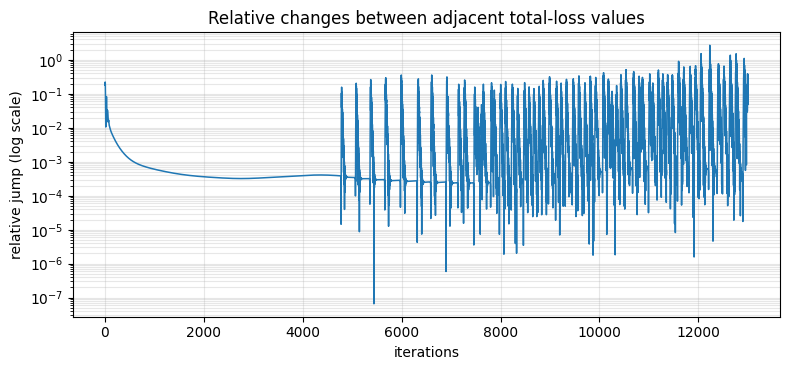

In [27]:
# Smoothness diagnostics: relative jumps |L[i]-L[i-1]| / L[i-1]
steps = np.array(history["step"])
loss_vals = np.array(history["total"])
eps = 1e-12

rel_jump = np.abs(np.diff(loss_vals)) / (np.abs(loss_vals[:-1]) + eps)
jump_steps = steps[1:]

top_k = 10 if rel_jump.size >= 10 else rel_jump.size
top_idx = np.argsort(rel_jump)[-top_k:][::-1]

print("Top jumps (step, relative_change):")
for idx in top_idx:
    print(f"step={int(jump_steps[idx])}, rel_change={rel_jump[idx]:.6e}")

print("\nSummary:")
print(f"mean rel jump: {rel_jump.mean():.6e}")
print(f"median rel jump: {np.median(rel_jump):.6e}")
print(f"95th percentile: {np.percentile(rel_jump, 95):.6e}")

plt.figure(figsize=(8, 3.8))
plt.semilogy(jump_steps, rel_jump + eps, lw=1.1)
plt.xlabel("iterations")
plt.ylabel("relative jump (log scale)")
plt.title("Relative changes between adjacent total-loss values")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()
